# BPIC17 (Start/Complete Filtered) vs Simulated Log

This notebook evaluates a simulated log generated by the **start_complete** dual-lifecycle model.

Both logs are filtered to lifecycle transitions in `{start, complete}` before comparison.

In [ ]:
from pathlib import Path
import sys

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

cwd = Path.cwd().resolve()
if (cwd / "integration").exists():
    repo_root = cwd
elif (cwd.parent / "integration").exists():
    repo_root = cwd.parent
else:
    repo_root = cwd

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from integration.SimulationBenchmark import SimulationBenchmark

print("Repo root:", repo_root)

Repo root: D:\Repos\process-simulation-engine-1


In [ ]:
# Configure paths
ORIGINAL_LOG_PATH = repo_root / "Dataset" / "BPI Challenge 2017.xes"
# Update this if you store this simulation under a different name
SIMULATED_LOG_PATH = repo_root / "integration" / "output" / "simulated_log.csv"

if not ORIGINAL_LOG_PATH.exists():
    raise FileNotFoundError(f"Original log not found: {ORIGINAL_LOG_PATH}")
if not SIMULATED_LOG_PATH.exists():
    raise FileNotFoundError(f"Simulated log not found: {SIMULATED_LOG_PATH}")

print("Original log:", ORIGINAL_LOG_PATH)
print("Simulated log:", SIMULATED_LOG_PATH)

Original log: D:\Repos\process-simulation-engine-1\Dataset\BPI Challenge 2017.xes
Simulated log: D:\Repos\process-simulation-engine-1\integration\output\simulated_log.csv


In [ ]:
# Load logs
import pm4py

orig_df = pm4py.convert_to_dataframe(pm4py.read_xes(str(ORIGINAL_LOG_PATH)))
sim_df = pd.read_csv(SIMULATED_LOG_PATH)

for df in [orig_df, sim_df]:
    if "time:timestamp" in df.columns:
        df["time:timestamp"] = pd.to_datetime(df["time:timestamp"], format="mixed")

# Enforce start/complete filtering on BOTH logs
for name, df in [("orig", orig_df), ("sim", sim_df)]:
    if "lifecycle:transition" not in df.columns:
        raise ValueError(f"{name} log has no lifecycle:transition column")

orig_sc = orig_df[orig_df["lifecycle:transition"].astype(str).str.lower().isin(["start", "complete"])].copy()
sim_sc = sim_df[sim_df["lifecycle:transition"].astype(str).str.lower().isin(["start", "complete"])].copy()

print("Original events (filtered):", len(orig_sc), "| cases:", orig_sc["case:concept:name"].nunique())
print("Simulated events (filtered):", len(sim_sc), "| cases:", sim_sc["case:concept:name"].nunique())

Original events (filtered): 603533 | cases: 31509
Simulated events (filtered): 2045 | cases: 100


In [ ]:
benchmark = SimulationBenchmark(
    original_log=orig_sc,
    simulated_log=sim_sc,
    filter_lifecycle_complete=False,
)

results = benchmark.compute_all_metrics()
results["simple_metrics"]

Computing benchmark metrics...
  - Basic statistics...
  - Events per case...
  - Case throughput time...
  - Case arrivals...
  - Case completions...
  - Control flow (DFG)...
  - Trace variants...
  - Start/End activities...
  - Activity durations...
  - Overall activity distribution...
  - Simple similarity metrics...
  - Resource statistics...
Benchmark computation complete!


,Metric,Value,Percentage
0,Activity Overlap,23 / 26 activities,88.461538
1,Activity Jaccard Similarity,0.8846,88.461538
2,Trace Variant Overlap,23 / 6797 variants,0.338385
3,Trace Variant Jaccard Similarity,0.0034,0.335619
4,Top 10 Variant Overlap,3 / 10 variants,30.000000
5,DFG Edge Overlap,63 / 184 edges,34.239130
6,DFG Edge Jaccard Similarity,0.3316,33.157895
7,Top 20 DFG Edge Overlap,18 / 20 edges,90.000000
8,Case Count Ratio,100 / 31509 cases,0.317370
9,Event Count Ratio,2045 / 603533 events,0.338838


In [ ]:
results["basic_stats"]

,Log,Number of Events,Number of Cases,Number of Unique Activities,Number of Unique Resources
0,Original,603533,31509,26,146
1,Simulated,2045,100,23,75


In [ ]:
results["events_per_case"]

,Log,Mean,Median,P90,Max
0,Original,19.154305,18.0,28.0,67
1,Simulated,20.450000,19.0,30.1,73


In [ ]:
results["throughput_time"]

,Log,Mean (hours),Median (hours),P75 (hours),P90 (hours),P95 (hours),Max (hours)
0,Original,524.416305,457.426639,755.760118,839.984945,1016.237075,4057.738839
1,Simulated,346.984211,329.480288,410.102123,485.818929,525.149290,939.460290


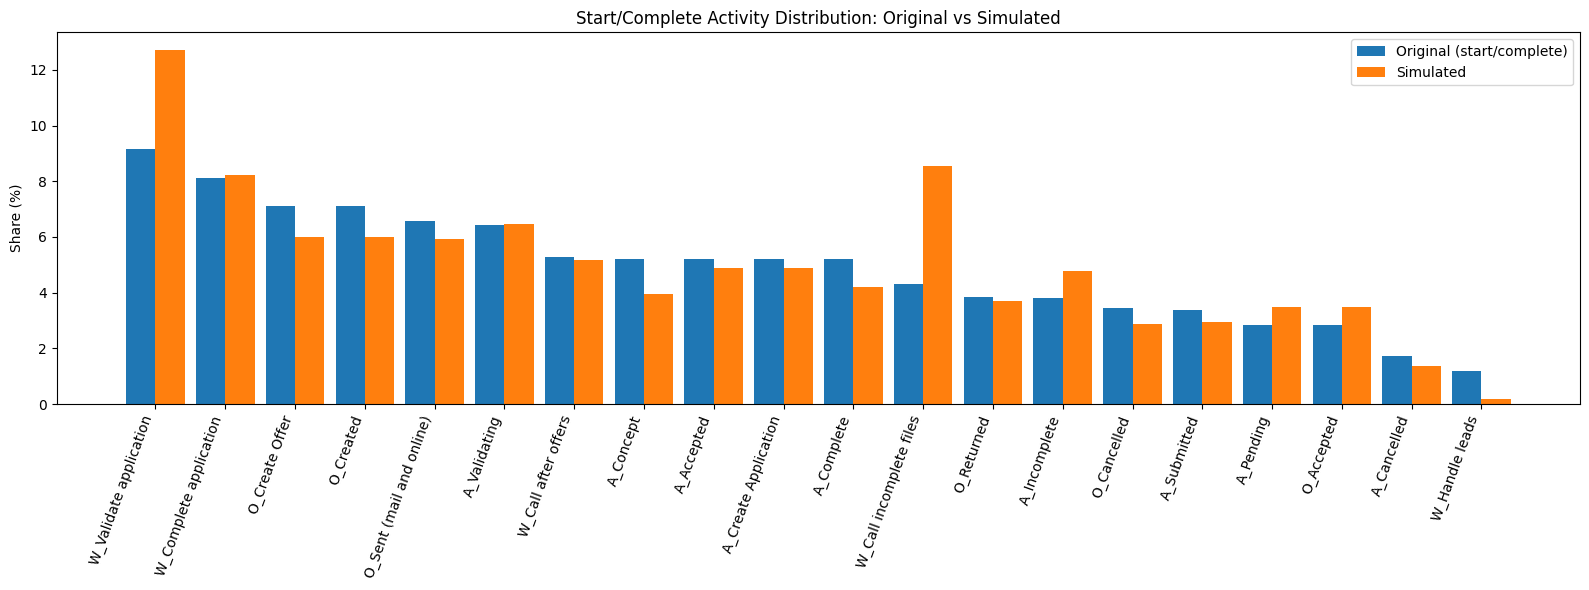

,Activity,Original Share (%),Simulated Share (%),Share Difference (%)
17,W_Validate application,9.161388,12.713936,3.552548
15,W_Complete application,8.122505,8.215159,0.092654
9,O_Create Offer,7.123886,6.014670,-1.109216
8,O_Created,7.123886,6.014670,-1.109216
21,O_Sent (mail and online),6.579093,5.916870,-0.662223
2,A_Validating,6.431463,6.454768,0.023305
1,W_Call after offers,5.273448,5.183374,-0.090074
22,A_Concept,5.220758,3.960880,-1.259878
6,A_Accepted,5.220758,4.889976,-0.330783
3,A_Create Application,5.220758,4.889976,-0.330783


In [ ]:
# Activity distribution comparison (top-20)
activity_cmp = results["activity_distribution"].copy()
activity_top20 = activity_cmp.sort_values("Original Count", ascending=False).head(20)

x = np.arange(len(activity_top20))
width = 0.42

plt.figure(figsize=(16, 6))
plt.bar(x - width/2, activity_top20["Original Share (%)"], width=width, label="Original (start/complete)")
plt.bar(x + width/2, activity_top20["Simulated Share (%)"], width=width, label="Simulated")
plt.xticks(x, activity_top20["Activity"], rotation=70, ha="right")
plt.ylabel("Share (%)")
plt.title("Start/Complete Activity Distribution: Original vs Simulated")
plt.legend()
plt.tight_layout()
plt.show()

activity_top20[["Activity", "Original Share (%)", "Simulated Share (%)", "Share Difference (%)"]]

In [ ]:
results["variants_comparison"].head(20)

,Variant,Original Count,Original Share (%),Original Rank,Simulated Count,Simulated Share (%),Simulated Rank
16,A_Create Application → A_Submitted → A_Concept...,2136,6.779016,1.0,3,3.0,4.0
6,A_Create Application → A_Submitted → A_Concept...,1490,4.728808,2.0,5,5.0,1.0
12,A_Create Application → W_Complete application ...,1238,3.929036,3.0,1,1.0,12.0
3,A_Create Application → A_Submitted → A_Concept...,603,1.913739,4.0,0,0.0,NaN
19,A_Create Application → A_Submitted → A_Concept...,499,1.583675,5.0,3,3.0,4.0
31,A_Create Application → A_Concept → W_Complete ...,488,1.548764,6.0,0,0.0,NaN
22,A_Create Application → W_Complete application ...,470,1.491637,7.0,0,0.0,NaN
34,A_Create Application → A_Submitted → W_Handle ...,450,1.428163,8.0,0,0.0,NaN
11,A_Create Application → A_Submitted → W_Handle ...,424,1.345647,9.0,0,0.0,NaN
35,A_Create Application → W_Complete application ...,412,1.307563,10.0,0,0.0,NaN


In [ ]:
results["dfg_comparison"].head(25)

,From,To,Original Count,Original Share (%),Original Rank,Simulated Count,Simulated Share (%),Simulated Rank
18,O_Create Offer,O_Created,42995,7.516293,1,123,6.323907,2
26,W_Validate application,A_Validating,38816,6.785729,2,128,6.580977,1
5,O_Created,O_Sent (mail and online),36187,6.326133,3,110,5.655527,3
31,A_Accepted,O_Create Offer,31430,5.494525,4,100,5.141388,4
13,W_Call after offers,A_Complete,31362,5.482637,5,82,4.215938,8
2,W_Call incomplete files,A_Incomplete,23055,4.030425,6,98,5.038560,6
12,A_Validating,O_Returned,21528,3.763478,7,69,3.547558,10
16,A_Create Application,A_Submitted,20423,3.570305,8,59,3.033419,12
21,W_Complete application,W_Call after offers,19032,3.327133,9,49,2.519280,18
0,O_Sent (mail and online),W_Complete application,18697,3.268569,10,49,2.519280,18


In [ ]:
print("Start activities")
display(results["start_activities"].head(20))

print("End activities")
display(results["end_activities"].head(20))

Start activities


,Activity,Original Count,Original Share (%),Simulated Count,Simulated Share (%)
0,A_Create Application,31509,100.0,100,100.0


End activities


,Activity,Original Count,Original Share (%),Simulated Count,Simulated Share (%)
5,O_Cancelled,14051,44.593608,49,49.0
15,A_Pending,10287,32.647815,47,47.0
8,W_Validate application,4036,12.809039,4,4.0
14,O_Refused,1977,6.274398,0,0.0
0,W_Call incomplete files,631,2.002602,0,0.0
6,W_Call after offers,136,0.431623,0,0.0
17,A_Cancelled,119,0.377670,0,0.0
16,W_Assess potential fraud,93,0.295154,0,0.0
3,W_Complete application,62,0.196769,0,0.0
9,A_Complete,30,0.095211,0,0.0


In [ ]:
# Optional export
OUT_XLSX = repo_root / "integration" / "output" / "bpic17_start_complete_vs_simulation_benchmark.xlsx"
benchmark.export_results(str(OUT_XLSX))
print("Exported:", OUT_XLSX)

Results exported to D:\Repos\process-simulation-engine-1\integration\output\bpic17_start_complete_vs_simulation_benchmark.xlsx
Exported: D:\Repos\process-simulation-engine-1\integration\output\bpic17_start_complete_vs_simulation_benchmark.xlsx
